<a href="https://colab.research.google.com/github/fargonemaciel/infnet-machine-learning-codes/blob/main/model_lifecycle_fargone_maciel_flor_DR1_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Inteligência Artificial: Model LifeCycle [26E1_1]

### Teste de Performance - TP3 [Obrigatório]

Para realizar os exercícios, você utilizará o Dataset de Obesidade do repositório UCI, o qual deve ser acessado no link abaixo. Antes de iniciar o exercício, leia a descrição do dataset para entender o significado dos exemplos.

Link: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

**1 Fases do Aprendizado de Máquina**

1. Crie um DataFrame pandas a partir do Dataset de Obesidade e prepare-o para utilização, removendo todos os exemplos que contenham valores de atributos nulos e substituindo quaisquer valores nominais por valores numéricos.
2. Divida o Dataset de Obesidade em três conjuntos: conjunto de teste, conjunto de validação e conjunto de teste.
3. Treine modelos de Classificação K-NN para 50 diferentes valores de K igualmente espaçados no intervalo [2, 100].
4. Avalie a taxa de erro para cada valor de K para o conjunto de validação.
5. Avalie o valor de K que apresentou o melhor desempenho com o conjunto de teste.
6. Imprima todos os valores de K e das métricas utilizadas para avaliar a taxa de erro. Além disso, indique qual foi o melhor valor de K.

**2 Overfitting, Underfitting e Generalização**

1. Divida o Dataset de Obesidade em dois conjuntos: conjunto de treinamento e conjunto de teste.
2. Adicione um ruído para cada valor do atributo ‘Weight’. Este ruído deve ser uniforme, variando no intervalo [-100, 100].
3. Treine modelos de Classificação K-NN para 50 diferentes valores de K igualmente espaçados no intervalo [2, 100].
4. Avalie a métrica acurácia para cada valor de K para o conjunto de treino e guarde em uma lista chamada acuracias_treino.
5. Avalie a métrica acurácia para cada valor de K para o conjunto de teste e guarde em uma lista chamada acuracias_teste.
6. Plote um gráfico com os valores de K no eixo-x e as acurácias de treinamento e teste no eixo-y. As acurácias de treinamento e teste devem ser plotadas nas cores verde e azul, respectivamente.
7. Assuma que uma acurácia menor do que 50% corresponde a uma baixa complexidade do modelo. Para algum valor de K, ocorreu overfitting ou underfitting? Se sim, a partir de qual valor de K? O modelo generalizou para algum valor de K? Qual valor e por quê? Justifique sua resposta com informações do gráfico.

**3 Validação Cruzada e Variância de Modelo**

1. Divida o Dataset de Obesidade em dois conjuntos: conjunto de treinamento e conjunto de teste.
2. Treine modelos de Classificação K-NN para 50 diferentes valores de K igualmente espaçados no intervalo [2, 100].
3. Realize Validação Cruzada de 5-folds para cada valor de K.
4. Mostre os erros de classificação e variância do modelo.
5. Plote um gráfico em que no eixo-x estão dispostos os valores de k e no eixo-y a variância do modelo. Interprete o gráfico e indique como/se o parâmetro K influencia na variância do modelo.

In [1]:
!pip install ucimlrepo

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [3]:
# Escolhi acessar o arquivo pelo código fornecido no link do exercício.

# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)

# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets


In [4]:
1. # Criando o DataFrame

df = pd.concat([X, y], axis=1)
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [5]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [6]:
df.nunique()

,0
Gender,2
Age,1402
Height,1574
Weight,1525
family_history_with_overweight,2
FAVC,2
FCVC,810
NCP,635
CAEC,4
SMOKE,2


In [7]:
cols_categoricas = df.select_dtypes(include='object').columns
cols_categoricas

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [8]:
for col in df[cols_categoricas].columns:
  print(f"\nColuna: {col}")
  print(df[col].value_counts())


Coluna: Gender
Gender
Male      1068
Female    1043
Name: count, dtype: int64

Coluna: family_history_with_overweight
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

Coluna: FAVC
FAVC
yes    1866
no      245
Name: count, dtype: int64

Coluna: CAEC
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

Coluna: SMOKE
SMOKE
no     2067
yes      44
Name: count, dtype: int64

Coluna: SCC
SCC
no     2015
yes      96
Name: count, dtype: int64

Coluna: CALC
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

Coluna: MTRANS
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

Coluna: NObeyesdad
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Le

In [9]:
map_dict = {}

for col in cols_categoricas:
  valores_unicos = sorted(df[col].unique())
  map_dict[col] = {valor: i for i, valor in enumerate(valores_unicos)}
  print(valores_unicos)
  print(map_dict[col])

['Female', 'Male']
{'Female': 0, 'Male': 1}
['no', 'yes']
{'no': 0, 'yes': 1}
['no', 'yes']
{'no': 0, 'yes': 1}
['Always', 'Frequently', 'Sometimes', 'no']
{'Always': 0, 'Frequently': 1, 'Sometimes': 2, 'no': 3}
['no', 'yes']
{'no': 0, 'yes': 1}
['no', 'yes']
{'no': 0, 'yes': 1}
['Always', 'Frequently', 'Sometimes', 'no']
{'Always': 0, 'Frequently': 1, 'Sometimes': 2, 'no': 3}
['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']
{'Automobile': 0, 'Bike': 1, 'Motorbike': 2, 'Public_Transportation': 3, 'Walking': 4}
['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
{'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}


In [10]:
map_dict

{'Gender': {'Female': 0, 'Male': 1},
 'family_history_with_overweight': {'no': 0, 'yes': 1},
 'FAVC': {'no': 0, 'yes': 1},
 'CAEC': {'Always': 0, 'Frequently': 1, 'Sometimes': 2, 'no': 3},
 'SMOKE': {'no': 0, 'yes': 1},
 'SCC': {'no': 0, 'yes': 1},
 'CALC': {'Always': 0, 'Frequently': 1, 'Sometimes': 2, 'no': 3},
 'MTRANS': {'Automobile': 0,
  'Bike': 1,
  'Motorbike': 2,
  'Public_Transportation': 3,
  'Walking': 4},
 'NObeyesdad': {'Insufficient_Weight': 0,
  'Normal_Weight': 1,
  'Obesity_Type_I': 2,
  'Obesity_Type_II': 3,
  'Obesity_Type_III': 4,
  'Overweight_Level_I': 5,
  'Overweight_Level_II': 6}}

In [11]:
map_dict['Gender']

{'Female': 0, 'Male': 1}

In [12]:
# Aplicando o dicionário para transformar os dados categóricos em numéricos

for col in cols_categoricas:
  df[col] = df[col].map(map_dict[col])

In [13]:
df.head(3)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   int64  
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   int64  
 5   FAVC                            2111 non-null   int64  
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   int64  
 9   SMOKE                           2111 non-null   int64  
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   int64  
 12  FAF                             21

In [15]:
# Removendo valores nulos

df = df.dropna()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   int64  
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   int64  
 5   FAVC                            2111 non-null   int64  
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   int64  
 9   SMOKE                           2111 non-null   int64  
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   int64  
 12  FAF                             21

In [17]:
# Analisando a distribuição da variável target

df['NObeyesdad'].value_counts()

,count
NObeyesdad,
2,351
4,324
3,297
5,290
6,290
1,287
0,272


In [18]:
2. # Separando conjunto de treino, validação e teste

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_treino, X_teste_val, y_treino, y_teste_val = train_test_split(X, y, train_size=0.6, random_state=250, stratify=y)

X_teste, X_val, y_teste, y_val = train_test_split(X_teste_val, y_teste_val, train_size=0.5, random_state=250, stratify=y_teste_val)



In [19]:
print(f"X_treino: {X_treino.shape}")
print(f"X_teste: {X_teste.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_treino: {y_treino.shape}")
print(f"y_teste: {y_teste.shape}")
print(f"y_val: {y_val.shape}")

X_treino: (1266, 16)
X_teste: (422, 16)
X_val: (423, 16)
y_treino: (1266,)
y_teste: (422,)
y_val: (423,)


In [20]:
3. # Treinando um modelo de classificação knn para 50 valores de k entre [2, 100]

valores_k = range(2, 101, 2)

erros_validacao = []

for k in valores_k:
  knn_classificador = KNeighborsClassifier(n_neighbors=k)
  knn_classificador.fit(X_treino, y_treino)
  y_pred_val = knn_classificador.predict(X_val)
  acuracia_val = accuracy_score(y_val, y_pred_val)
  erro_val = 1 - acuracia_val

  erros_validacao.append((k, erro_val))

df_resultados_val = pd.DataFrame(erros_validacao, columns=['K', 'Erros_Validação'])

In [21]:
4. # Taxa de erro para cada valor de K no conjunto de validação

df_resultados_val.sort_values(by='Erros_Validação', ascending=True).head(5)

,K,Erros_Validação
0,2,0.153664
1,4,0.163121
2,6,0.163121
3,8,0.189125
4,10,0.203310


In [22]:
6. # Indicação do melhor valor de K

melhor_resultado = df_resultados_val.loc[df_resultados_val['Erros_Validação'].idxmin()]

melhor_k = melhor_resultado['K']

print(melhor_k)

2.0


In [23]:
5. # Avaliando o melhor valor de K para o conjunto de teste

knn_classificador_final = KNeighborsClassifier(n_neighbors=int(melhor_k))
knn_classificador_final.fit(X_treino, y_treino)
y_pred_teste = knn_classificador_final.predict(X_teste)
acuracia_teste = accuracy_score(y_teste, y_pred_teste)
erro_teste = 1 - acuracia_teste

print(f"Acurácia no conjunto de teste: {acuracia_teste:.4f}")
print(f"Erro no conjunto de teste: {erro_teste:.4f}")


Acurácia no conjunto de teste: 0.8649
Erro no conjunto de teste: 0.1351


###  Overfitting, Underfitting e Generalização

In [24]:
1. # Divindo o conjunto de dados apenas em treino e teste.

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=0.7, random_state=200, stratify=y)

print(f"X_treino: {X_treino.shape}")
print(f"X_teste: {X_teste.shape}")
print(f"y_treino: {y_treino.shape}")
print(f"y_teste: {y_teste.shape}")

X_treino: (1477, 16)
X_teste: (634, 16)
y_treino: (1477,)
y_teste: (634,)


In [25]:
2. # Adicionando ruído para cada valor da feature 'Weight'

X_treino['Weight'].describe()

,Weight
count,1477.000000
mean,86.717947
std,26.326965
min,39.000000
25%,66.000000
50%,82.694689
75%,108.244379
max,173.000000


In [26]:
ruido = np.random.uniform(-100, 100, size=len(X_treino))
X_treino['Weight'] = X_treino['Weight'] + ruido

ruido

X_treino['Weight'].describe()

,Weight
count,1477.000000
mean,86.831584
std,63.479838
min,-51.924517
25%,36.554193
50%,87.156363
75%,136.320259
max,264.360829


In [27]:
3. # Treinando o modelo de classificação para 50 valores diferentes de K intervalados entre 2, 100

valores_k = range(2, 101, 2)

acuracias_treino = []
acuracias_teste = []

for k in valores_k:
  knn_classificador = KNeighborsClassifier(n_neighbors=k)
  knn_classificador.fit(X_treino, y_treino)
  y_pred_treino = knn_classificador.predict(X_treino)
  acuracia_treino = accuracy_score(y_treino, y_pred_treino)
  y_pred_teste = knn_classificador.predict(X_teste)
  acuracia_teste = accuracy_score(y_teste, y_pred_teste)

  acuracias_treino.append((k, acuracia_treino))
  acuracias_teste.append((k, acuracia_teste))

In [28]:
4. # Avaliando a métrica de acurácia para os valores de K no conjunto de treino

df_resultados_treino = pd.DataFrame(acuracias_treino, columns=['K', 'Acurácia_Treino'])
df_resultados_treino.sort_values(by='Acurácia_Treino', ascending=False).head(5)

,K,Acurácia_Treino
0,2,0.725796
1,4,0.619499
2,6,0.553148
3,8,0.513879
4,10,0.484766


In [29]:
5. # Avaliando a métrica de acurácia para os valores de K no conjunto de teste

df_resultados_teste = pd.DataFrame(acuracias_teste, columns=['K', 'Acurácia_Teste'])
df_resultados_teste.sort_values(by='Acurácia_Teste', ascending=False).head(5)

,K,Acurácia_Teste
3,8,0.359621
0,2,0.350158
1,4,0.350158
2,6,0.342271
4,10,0.332808


#### Na base de treino, só o k igual a 2 que deu performance maior, porém na base de teste os resultados estão bem abaixo. Significando overfttingn na base de treino. A causa é nitidamente o ruído colocado em uma variável.

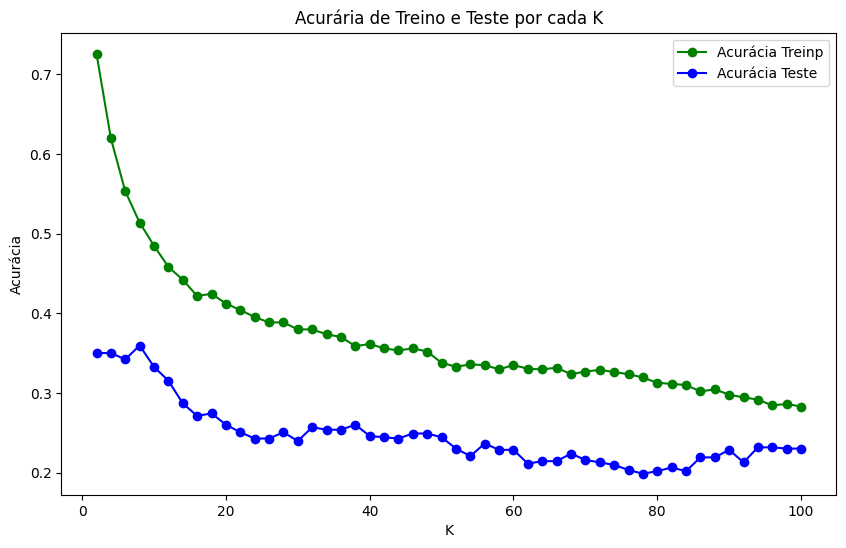

In [30]:
# 6. Gráficos

plt.figure(figsize=(10, 6))

plt.plot(df_resultados_treino['K'], df_resultados_treino['Acurácia_Treino'], color='green', label='Acurácia Treinp', marker='o')
plt.plot(df_resultados_teste['K'], df_resultados_teste['Acurácia_Teste'], color='blue', label='Acurácia Teste', marker='o')

plt.xlabel('K')
plt.ylabel('Acurácia')
plt.title('Acurária de Treino e Teste por cada K')
plt.legend()

plt.show()

**Resposta do exercício 7**:
Overfitting: houve para o K por volta de 2, pois performou muito bem na base de treino, mas na base de teste o resultado foi muito abaixo, ou seja, houve uma grande diferença.
Underfitting: também aconteceu para valores de acima de mais ou menos 40, onde tanto na base de treino quanto na base de testo, o modelo não consegue entender os padrões e consequentemente generalizar.
O modelo generalizou melhor para um k de 8, pois apesar de uma performance menor que outros K, a acuracia aumentou nesse ponto.

### 3 Validação Cruzada e Variância de Modelo

In [32]:
1. # Divindo o conjunto de dados apenas em treino e teste.

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=0.7, random_state=200, stratify=y)

print(f"X_treino: {X_treino.shape}")
print(f"X_teste: {X_teste.shape}")
print(f"y_treino: {y_treino.shape}")
print(f"y_teste: {y_teste.shape}")

X_treino: (1477, 16)
X_teste: (634, 16)
y_treino: (1477,)
y_teste: (634,)


In [35]:
2. # Treinando o modelo de classificação para 50 valores diferentes de K intervalados entre 2, 100

valores_k = range(2, 101, 2)

acuracias_treino = []
acuracias_teste = []

for k in valores_k:
  knn_classificador = KNeighborsClassifier(n_neighbors=k)
  knn_classificador.fit(X_treino, y_treino)
  y_pred_treino = knn_classificador.predict(X_treino)
  acuracia_treino = accuracy_score(y_treino, y_pred_treino)
  y_pred_teste = knn_classificador.predict(X_teste)
  acuracia_teste = accuracy_score(y_teste, y_pred_teste)

  acuracias_treino.append((k, acuracia_treino))
  acuracias_teste.append((k, acuracia_teste))

In [39]:
3. # Realizando Validação Cruzada de 5-folds para cada valor de K

acuracias_val = []

for k in valores_k:
  knn_classificador = KNeighborsClassifier(n_neighbors=k)
  acuracia_val = cross_val_score(knn_classificador, X, y, cv=5, scoring='accuracy')
  media_acuracia = np.mean(acuracia_val)
  acuracias_val.append((k, media_acuracia))

In [40]:
df_resultados_val = pd.DataFrame(acuracias_val, columns=['K', 'Acurácia_Validação'])
df_resultados_val.head().sort_values(by='Acurácia_Validação', ascending=False)

,K,Acurácia_Validação
0,2,0.880663
1,4,0.875445
2,6,0.861711
3,8,0.848444
4,10,0.839910
